# Download ERA5 Temperature Data for Additional Regions

This notebook downloads ERA5 monthly mean temperature data for:
- **East Africa** (Uganda, Kenya, Tanzania)
- **Madagascar**
- **Brazil**

## Prerequisites
1. CDS API account: https://cds.climate.copernicus.eu/
2. Install cdsapi: `pip install cdsapi`
3. Setup `~/.cdsapirc` with your API credentials

## 1. Install Required Packages

In [1]:
# Install required packages if not already installed
!pip3 install cdsapi xarray netCDF4


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 2. Import Libraries

In [2]:
import cdsapi
import numpy as np
import xarray as xr
from pathlib import Path
import os

## 3. Define Region Configurations

Each region has:
- **Bounding box**: [North, West, South, East] coordinates
- **Cities**: Key cities to display on heat maps

In [3]:
REGIONS = {
    'east_africa': {
        'name': 'East Africa (Uganda, Kenya, Tanzania)',
        'area': [5, 29, -12, 42],  # [North, West, South, East]
        'cities': {
            'KAMPALA': {'lat': 0.3476, 'lon': 32.5825, 'name': 'Kampala'},
            'NAIROBI': {'lat': -1.2921, 'lon': 36.8219, 'name': 'Nairobi'},
            'MOMBASA': {'lat': -4.0435, 'lon': 39.6682, 'name': 'Mombasa'},
            'DAR': {'lat': -6.7924, 'lon': 39.2083, 'name': 'Dar es Salaam'},
            'ARUSHA': {'lat': -3.3869, 'lon': 36.6830, 'name': 'Arusha'},
            'KISUMU': {'lat': -0.1022, 'lon': 34.7617, 'name': 'Kisumu'},
        }
    },
    'madagascar': {
        'name': 'Madagascar',
        'area': [-11.5, 43, -26, 51],  # [North, West, South, East]
        'cities': {
            'ANTANANARIVO': {'lat': -18.8792, 'lon': 47.5079, 'name': 'Antananarivo'},
            'TOAMASINA': {'lat': -18.1443, 'lon': 49.3958, 'name': 'Toamasina'},
            'MAHAJANGA': {'lat': -15.7167, 'lon': 46.3167, 'name': 'Mahajanga'},
            'FIANARANTSOA': {'lat': -21.4417, 'lon': 47.0833, 'name': 'Fianarantsoa'},
            'TOLIARA': {'lat': -23.3500, 'lon': 43.6667, 'name': 'Toliara'},
        }
    },
    'brazil': {
        'name': 'Brazil',
        'area': [6, -74, -34, -34],  # [North, West, South, East]
        'cities': {
            'SAO_PAULO': {'lat': -23.5505, 'lon': -46.6333, 'name': 'São Paulo'},
            'RIO': {'lat': -22.9068, 'lon': -43.1729, 'name': 'Rio de Janeiro'},
            'BRASILIA': {'lat': -15.7975, 'lon': -47.8919, 'name': 'Brasília'},
            'SALVADOR': {'lat': -12.9714, 'lon': -38.5014, 'name': 'Salvador'},
            'MANAUS': {'lat': -3.1190, 'lon': -60.0217, 'name': 'Manaus'},
            'RECIFE': {'lat': -8.0476, 'lon': -34.8770, 'name': 'Recife'},
            'BELEM': {'lat': -1.4558, 'lon': -48.4902, 'name': 'Belém'},
        }
    }
}

# Variables for temperature analysis
VARIABLES = ['2m_temperature']

# Output directory
OUTPUT_DIR = 'era5_regional_data'
Path(OUTPUT_DIR).mkdir(exist_ok=True)

print("Region configurations loaded!")
for key, region in REGIONS.items():
    print(f"\n{region['name']}:")
    print(f"  Bounding box [N, W, S, E]: {region['area']}")
    print(f"  Cities: {', '.join([c['name'] for c in region['cities'].values()])}")

Region configurations loaded!

East Africa (Uganda, Kenya, Tanzania):
  Bounding box [N, W, S, E]: [5, 29, -12, 42]
  Cities: Kampala, Nairobi, Mombasa, Dar es Salaam, Arusha, Kisumu

Madagascar:
  Bounding box [N, W, S, E]: [-11.5, 43, -26, 51]
  Cities: Antananarivo, Toamasina, Mahajanga, Fianarantsoa, Toliara

Brazil:
  Bounding box [N, W, S, E]: [6, -74, -34, -34]
  Cities: São Paulo, Rio de Janeiro, Brasília, Salvador, Manaus, Recife, Belém


## 4. Define Download Functions

In [4]:
def download_era5_region(region_key, year_start=1974, year_end=2024, output_dir=OUTPUT_DIR):
    """
    Download ERA5 temperature data for a specific region.
    
    Args:
        region_key: 'east_africa', 'madagascar', or 'brazil'
        year_start: Start year
        year_end: End year
        output_dir: Directory to save files
    
    Returns:
        Path to downloaded file
    """
    region = REGIONS[region_key]
    
    output_file = f"{output_dir}/era5_{region_key}_{year_start}_{year_end}.nc"
    
    print(f"\n{'='*80}")
    print(f"Downloading ERA5 data for {region['name']}")
    print(f"Area: {region['area']} [North, West, South, East]")
    print(f"Years: {year_start}-{year_end}")
    print(f"Output: {output_file}")
    print('='*80)
    
    c = cdsapi.Client()
    
    # Generate year list
    years = [str(y) for y in range(year_start, year_end + 1)]
    
    try:
        c.retrieve(
            'reanalysis-era5-single-levels-monthly-means',
            {
                'product_type': 'monthly_averaged_reanalysis',
                'format': 'netcdf',
                'variable': VARIABLES,
                'year': years,
                'month': [
                    '01', '02', '03', '04', '05', '06',
                    '07', '08', '09', '10', '11', '12',
                ],
                'time': '00:00',
                'area': region['area'],
            },
            output_file
        )
        
        print(f"\n✓ Successfully downloaded: {output_file}")
        
        # Check file size
        size_mb = Path(output_file).stat().st_size / (1024 * 1024)
        print(f"  File size: {size_mb:.1f} MB")
        
        return output_file
        
    except Exception as e:
        print(f"\n✗ Error downloading {region_key}: {e}")
        return None

In [5]:
def verify_data(nc_file, region_key):
    """
    Verify downloaded data and print summary statistics.
    """
    region = REGIONS[region_key]
    
    print(f"\n{'='*80}")
    print(f"VERIFYING: {region['name']}")
    print('='*80)
    
    try:
        ds = xr.open_dataset(nc_file)
        
        print(f"\nVariables: {list(ds.data_vars)}")
        print(f"Dimensions: {dict(ds.dims)}")
        
        # Time info
        if 'time' in ds.dims:
            time_dim = 'time'
        elif 'valid_time' in ds.dims:
            time_dim = 'valid_time'
        else:
            time_dim = list(ds.dims.keys())[0]
        
        print(f"Time dimension: {time_dim}")
        print(f"Time range: {ds[time_dim].values[0]} to {ds[time_dim].values[-1]}")
        
        # Temperature stats
        if 't2m' in ds:
            temp_c = ds['t2m'] - 273.15  # Convert from Kelvin to Celsius
            print(f"\nTemperature Statistics (°C):")
            print(f"  Min: {float(temp_c.min()):.1f}°C")
            print(f"  Max: {float(temp_c.max()):.1f}°C")
            print(f"  Mean: {float(temp_c.mean()):.1f}°C")
        
        # Check city coordinates are within bounds
        print(f"\nCities in region:")
        lat_range = [float(ds.latitude.min()), float(ds.latitude.max())]
        lon_range = [float(ds.longitude.min()), float(ds.longitude.max())]
        
        for city_code, city_info in region['cities'].items():
            in_bounds = (lat_range[0] <= city_info['lat'] <= lat_range[1] and
                        lon_range[0] <= city_info['lon'] <= lon_range[1])
            status = "✓" if in_bounds else "✗ OUT OF BOUNDS"
            print(f"  {city_info['name']}: ({city_info['lat']:.2f}°, {city_info['lon']:.2f}°) {status}")
        
        ds.close()
        print("\n✓ Data verification complete")
        return True
        
    except Exception as e:
        print(f"\n✗ Error verifying data: {e}")
        return False

## 5. Download East Africa Data

**Region:** Uganda, Kenya, Tanzania  
**Bounding Box:** [5°N, 29°E, 12°S, 42°E]  
**Estimated file size:** ~50-100 MB

In [6]:
# Download East Africa data
east_africa_file = download_era5_region('east_africa', 1974, 2024)


Area: [5, 29, -12, 42] [North, West, South, East]
Years: 1974-2024
Output: era5_regional_data/era5_east_africa_1974_2024.nc


2025-12-01 11:50:06,205 INFO Request ID is 4d7796b9-f73f-4bde-a432-62542df0530b
2025-12-01 11:50:07,479 INFO status has been updated to accepted
2025-12-01 11:50:15,622 INFO status has been updated to running
2025-12-01 11:51:33,018 INFO status has been updated to successful
                                                                                        


✓ Successfully downloaded: era5_regional_data/era5_east_africa_1974_2024.nc
  File size: 3.6 MB


In [7]:
# Verify East Africa data
if east_africa_file and Path(east_africa_file).exists():
    verify_data(east_africa_file, 'east_africa')


VERIFYING: East Africa (Uganda, Kenya, Tanzania)

Variables: ['t2m']
Dimensions: {'valid_time': 612, 'latitude': 69, 'longitude': 53}
Time dimension: valid_time
Time range: 1974-01-01T00:00:00.000000000 to 2024-12-01T00:00:00.000000000

Temperature Statistics (°C):
  Min: 10.7°C
  Max: 35.0°C
  Mean: 23.7°C

Cities in region:
  Kampala: (0.35°, 32.58°) ✓
  Nairobi: (-1.29°, 36.82°) ✓
  Mombasa: (-4.04°, 39.67°) ✓
  Dar es Salaam: (-6.79°, 39.21°) ✓
  Arusha: (-3.39°, 36.68°) ✓
  Kisumu: (-0.10°, 34.76°) ✓

✓ Data verification complete


/var/folders/vf/46x16dqs7ws34_wqm_b56dzh0000gn/T/ipykernel_56575/2383892196.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")


## 6. Download Madagascar Data

**Region:** Madagascar  
**Bounding Box:** [11.5°S, 43°E, 26°S, 51°E]  
**Estimated file size:** ~30-60 MB

In [8]:
# Download Madagascar data
madagascar_file = download_era5_region('madagascar', 1974, 2024)


Area: [-11.5, 43, -26, 51] [North, West, South, East]
Years: 1974-2024
Output: era5_regional_data/era5_madagascar_1974_2024.nc


2025-12-01 11:51:54,147 INFO Request ID is cbdaa021-9750-43f0-832e-a292b2688381
2025-12-01 11:51:55,494 INFO status has been updated to accepted
2025-12-01 11:52:03,945 INFO status has been updated to running
2025-12-01 11:52:55,249 INFO status has been updated to successful
                                                                                        


✓ Successfully downloaded: era5_regional_data/era5_madagascar_1974_2024.nc
  File size: 1.9 MB


In [9]:
# Verify Madagascar data
if madagascar_file and Path(madagascar_file).exists():
    verify_data(madagascar_file, 'madagascar')


VERIFYING: Madagascar

Variables: ['t2m']
Dimensions: {'valid_time': 612, 'latitude': 59, 'longitude': 33}
Time dimension: valid_time
Time range: 1974-01-01T00:00:00.000000000 to 2024-12-01T00:00:00.000000000

Temperature Statistics (°C):
  Min: 9.4°C
  Max: 31.2°C
  Mean: 24.0°C

Cities in region:
  Antananarivo: (-18.88°, 47.51°) ✓
  Toamasina: (-18.14°, 49.40°) ✓
  Mahajanga: (-15.72°, 46.32°) ✓
  Fianarantsoa: (-21.44°, 47.08°) ✓
  Toliara: (-23.35°, 43.67°) ✓

✓ Data verification complete


/var/folders/vf/46x16dqs7ws34_wqm_b56dzh0000gn/T/ipykernel_56575/2383892196.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")


## 7. Download Brazil Data

**Region:** Brazil  
**Bounding Box:** [6°N, 74°W, 34°S, 34°W]  
**Estimated file size:** ~150-300 MB (larger region)

In [10]:
# Download Brazil data
brazil_file = download_era5_region('brazil', 1974, 2024)


Area: [6, -74, -34, -34] [North, West, South, East]
Years: 1974-2024
Output: era5_regional_data/era5_brazil_1974_2024.nc


2025-12-01 11:53:12,920 INFO Request ID is c007509e-3697-4751-8778-5b68d58f2d23
2025-12-01 11:53:14,121 INFO status has been updated to accepted
2025-12-01 11:53:22,208 INFO status has been updated to running
2025-12-01 11:53:54,239 INFO status has been updated to successful
                                                                                         


✓ Successfully downloaded: era5_regional_data/era5_brazil_1974_2024.nc
  File size: 25.1 MB


In [11]:
# Verify Brazil data
if brazil_file and Path(brazil_file).exists():
    verify_data(brazil_file, 'brazil')

/var/folders/vf/46x16dqs7ws34_wqm_b56dzh0000gn/T/ipykernel_56575/2383892196.py:15: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")



VERIFYING: Brazil

Variables: ['t2m']
Dimensions: {'valid_time': 612, 'latitude': 161, 'longitude': 161}
Time dimension: valid_time
Time range: 1974-01-01T00:00:00.000000000 to 2024-12-01T00:00:00.000000000

Temperature Statistics (°C):
  Min: -19.1°C
  Max: 33.6°C
  Mean: 22.8°C

Cities in region:
  São Paulo: (-23.55°, -46.63°) ✓
  Rio de Janeiro: (-22.91°, -43.17°) ✓
  Brasília: (-15.80°, -47.89°) ✓
  Salvador: (-12.97°, -38.50°) ✓
  Manaus: (-3.12°, -60.02°) ✓
  Recife: (-8.05°, -34.88°) ✓
  Belém: (-1.46°, -48.49°) ✓

✓ Data verification complete


## 8. Summary & Next Steps

In [12]:
# Print summary
print("="*80)
print("DOWNLOAD SUMMARY")
print("="*80)

files_created = []
for region_key in REGIONS.keys():
    file_path = f"{OUTPUT_DIR}/era5_{region_key}_1974_2024.nc"
    if Path(file_path).exists():
        size_mb = Path(file_path).stat().st_size / (1024 * 1024)
        print(f"✓ {file_path} ({size_mb:.1f} MB)")
        files_created.append(file_path)
    else:
        print(f"✗ {file_path} - NOT FOUND")

print(f"\nTotal files created: {len(files_created)}/{len(REGIONS)}")

DOWNLOAD SUMMARY
✓ era5_regional_data/era5_east_africa_1974_2024.nc (3.6 MB)
✓ era5_regional_data/era5_madagascar_1974_2024.nc (1.9 MB)
✓ era5_regional_data/era5_brazil_1974_2024.nc (25.1 MB)

Total files created: 3/3


In [13]:
# Copy files to main directory for app.py to use
import shutil

print("\nCopying files to main directory...")
for region_key in REGIONS.keys():
    src = f"{OUTPUT_DIR}/era5_{region_key}_1974_2024.nc"
    dst = f"era5_{region_key}_1974_2024.nc"
    
    if Path(src).exists():
        shutil.copy(src, dst)
        print(f"✓ Copied to {dst}")
    else:
        print(f"✗ Source file not found: {src}")

print("\nDone! Files are ready for use with app.py")


Copying files to main directory...
✓ Copied to era5_east_africa_1974_2024.nc
✓ Copied to era5_madagascar_1974_2024.nc
✓ Copied to era5_brazil_1974_2024.nc

Done! Files are ready for use with app.py


## 9. Quick Data Preview (Optional)

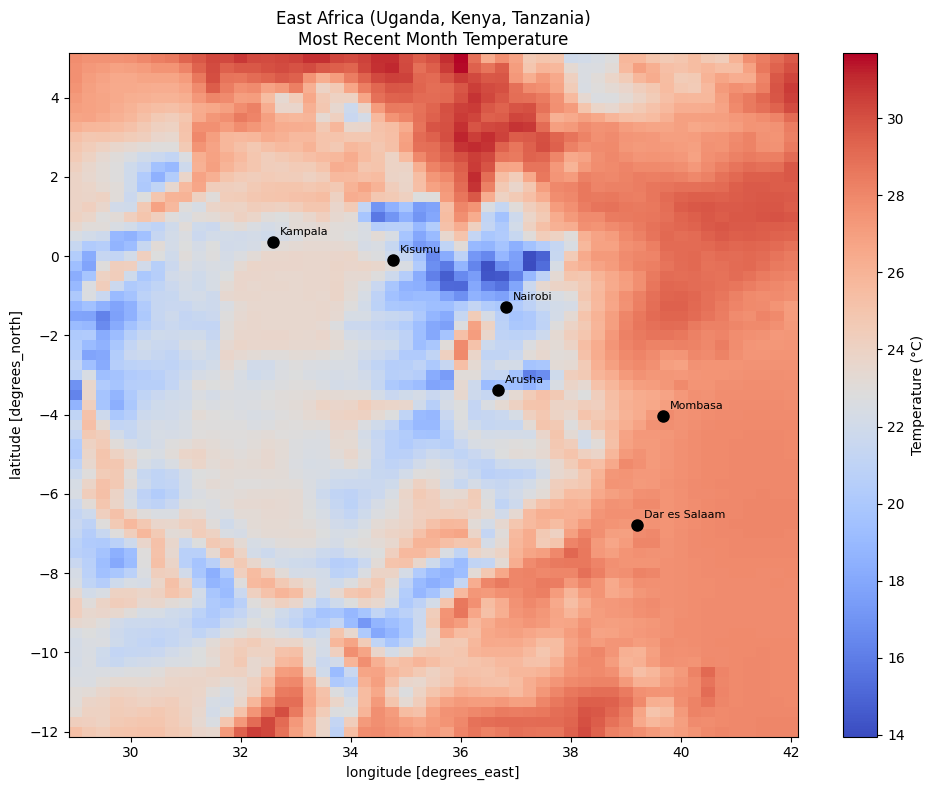

In [14]:
# Preview one of the datasets
import matplotlib.pyplot as plt

def preview_region(region_key):
    """Create a quick preview map of the downloaded data"""
    file_path = f"era5_{region_key}_1974_2024.nc"
    
    if not Path(file_path).exists():
        print(f"File not found: {file_path}")
        return
    
    ds = xr.open_dataset(file_path)
    region = REGIONS[region_key]
    
    # Get the last time step (most recent)
    time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
    temp_c = ds['t2m'].isel({time_dim: -1}) - 273.15
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    temp_c.plot(ax=ax, cmap='coolwarm', cbar_kwargs={'label': 'Temperature (°C)'})
    
    # Add city markers
    for city_code, city_info in region['cities'].items():
        ax.plot(city_info['lon'], city_info['lat'], 'ko', markersize=8)
        ax.annotate(city_info['name'], (city_info['lon'], city_info['lat']), 
                   xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax.set_title(f"{region['name']}\nMost Recent Month Temperature")
    plt.tight_layout()
    plt.show()
    
    ds.close()

# Preview East Africa
preview_region('east_africa')

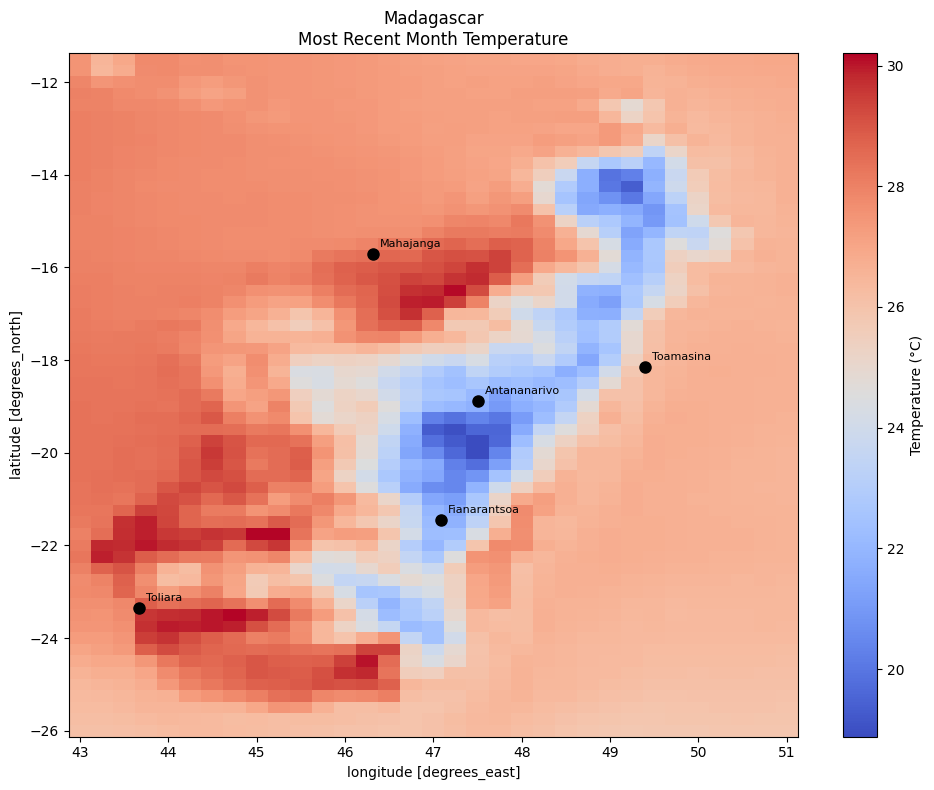

In [15]:
# Preview Madagascar
preview_region('madagascar')

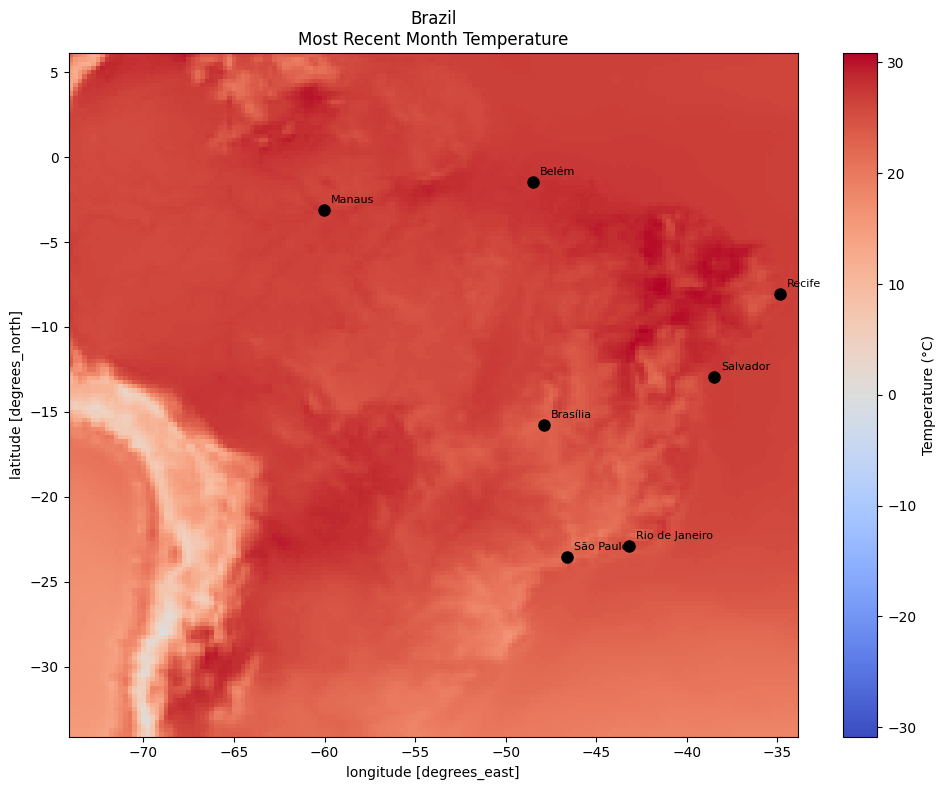

In [16]:
# Preview Brazil
preview_region('brazil')

---

## Next Steps

After downloading the data:

1. Make sure the `.nc` files are in the same directory as `app.py`
2. Update your `app.py` with the new tab code
3. Run your Streamlit app: `streamlit run app.py`

The expected file names are:
- `era5_east_africa_1974_2024.nc`
- `era5_madagascar_1974_2024.nc`
- `era5_brazil_1974_2024.nc`